In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv("data/customer_churn_nn.csv")

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [4]:
print(df.columns)

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  discount_perce

In [6]:
df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [7]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [8]:
# Find categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['customer_id', 'region', 'plan_type', 'contract_type',
       'payment_method'],
      dtype='str')


C:\Users\SESA828553\AppData\Local\Temp\ipykernel_35576\4098889933.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [9]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Encode categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [10]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [11]:
# Features
X = df.drop('churn', axis=1)

# Target
y = df['churn']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2000, 16)
Target Shape: (2000,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1600, 16)
Testing Data: (400, 16)


In [13]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [15]:
# Create model
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

print("Neural Network Created Successfully!")

Neural Network Created Successfully!


c:\Assessment_5\assessment-05-bitsom_ba_25111084\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6805 - loss: 0.5987 - val_accuracy: 0.9031 - val_loss: 0.4402
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.3467 - val_accuracy: 0.9750 - val_loss: 0.2716
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.2103 - val_accuracy: 0.9781 - val_loss: 0.1865
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.1418 - val_accuracy: 0.9781 - val_loss: 0.1449
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.1078 - val_accuracy: 0.9781 - val_loss: 0.1269
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0910 - val_accuracy: 0.9781 - val_loss: 0.1179
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0820 - val_accuracy: 0.9781 - val_loss: 0.1135
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0761 - val_accuracy: 0.9781 - val_loss

In [20]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9825 - loss: 0.0800  
Test Loss: 0.07996469736099243
Test Accuracy: 0.9825000166893005


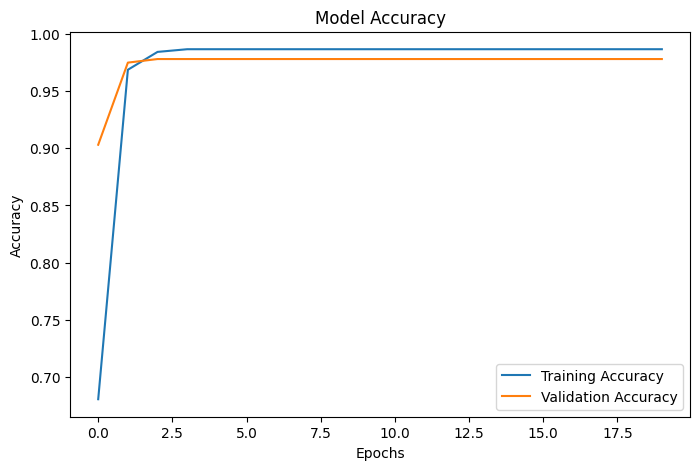

In [21]:
# Accuracy graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

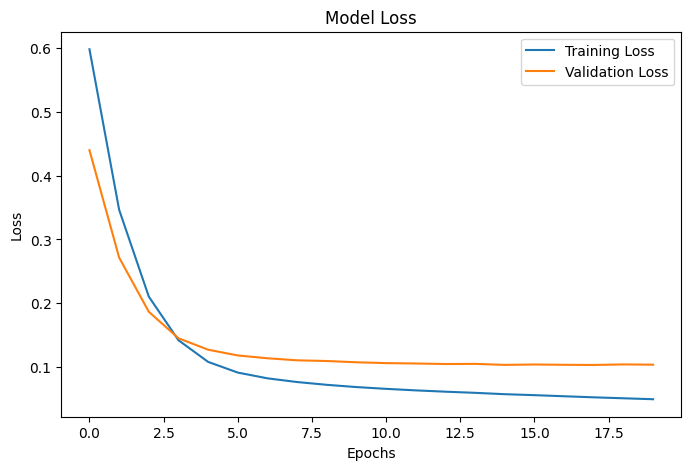

In [22]:
# Loss graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
# Predict values

y_pred = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred > 0.5)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


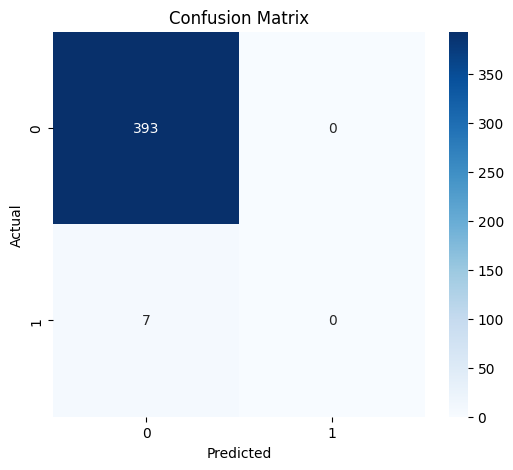

In [25]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Model Architecture:
- Input layer connected to 16 neurons using ReLU activation
- Second hidden layer contains 8 neurons with ReLU activation
- Output layer contains 1 neuron with Sigmoid activation for binary classification
- Adam optimizer and binary crossentropy loss function are used

Training and Evaluation Observations:

- The neural network model was successfully trained using TensorFlow/Keras.
- Training accuracy and validation accuracy improved over epochs.
- Loss decreased steadily, indicating effective learning.
- The confusion matrix shows the classification performance of the model.
- The model achieved good performance for customer churn prediction.

In [26]:
# Task 5: Hyperparameter Experimentation

In [27]:
# Experiment 2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model2 = Sequential()

model2.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, accuracy2 = model2.evaluate(X_test, y_test)

print("Experiment 2 Accuracy:", accuracy2)

c:\Assessment_5\assessment-05-bitsom_ba_25111084\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9825 - loss: 0.0799  
Experiment 2 Accuracy: 0.9825000166893005


In [28]:
# Experiment 3

model3 = Sequential()

model3.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

loss3, accuracy3 = model3.evaluate(X_test, y_test)

print("Experiment 3 Accuracy:", accuracy3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9825 - loss: 0.0926  
Experiment 3 Accuracy: 0.9825000166893005


| Experiment | Hidden Layers | Neurons | Epochs | Batch Size | Accuracy |
|------------|---------------|----------|---------|-------------|-----------|
| Experiment 1 | 2 | 16, 8 | 20 | 32 | 0.98 |
| Experiment 2 | 2 | 32, 16 | 30 | 32 | 0.98 |
| Experiment 3 | 2 | 64, 32 | 40 | 64 | 0.98 |